In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from scipy.special import ellipk, ellipkinc

# opcional
import matplotx
plt.style.use(matplotx.styles.dracula)

BASE = "/home/kingsman/Escritorio/PhD/PINN_paper/observable_final_run"
CKPT_PATH = os.path.join(BASE, "ckpt", "best.pt")
NORM_PATH = os.path.join(BASE, "tables", "normalization.json")
OUT_FIGS = os.path.join(BASE, "figs_final")
os.makedirs(OUT_FIGS, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cuda


In [2]:
class ObservableNet(torch.nn.Module):
    def __init__(self, in_dim, width=256, depth=4, dropout=0.05, out_dim=2):
        super().__init__()
        layers = []
        d = in_dim
        for _ in range(depth):
            layers += [
                torch.nn.Linear(d, width),
                torch.nn.GELU(),
                torch.nn.Dropout(dropout),
            ]
            d = width
        layers += [torch.nn.Linear(d, out_dim)]
        self.net = torch.nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def bcrit(Rs):
    return 1.5 * np.sqrt(3.0) * Rs


def cubic_roots_u(Rs, b):
    coeff = [1.0, -1.0, 0.0, (Rs / b) ** 2]
    roots = np.roots(coeff)
    roots = np.real_if_close(roots, tol=1e5)
    if np.any(np.abs(np.imag(roots)) > 1e-10):
        return None
    return np.sort(np.real(roots))


def scattering_observables_exact(Rs, b):
    roots = cubic_roots_u(Rs, b)
    if roots is None:
        return None

    u1, u2, u3 = roots
    if not (u1 < 0 < u2 < u3 < 1):
        return None

    m = (u2 - u1) / (u3 - u1)
    if not (0 <= m < 1):
        return None

    z = np.sqrt((-u1) / (u2 - u1))
    z = np.clip(z, 0.0, 1.0)

    K_complete = ellipk(m)
    F_incomplete = ellipkinc(np.arcsin(z), m)

    Delta_phi = 4.0 / np.sqrt(u3 - u1) * (K_complete - F_incomplete)
    delta_phi = Delta_phi - np.pi

    u_turn = u2
    r_min = Rs / u_turn
    rho_min = r_min / Rs
    N_wind = Delta_phi / (2.0 * np.pi)

    return {
        "delta_phi": float(delta_phi),
        "Delta_phi": float(Delta_phi),
        "rho_min": float(rho_min),
        "r_min": float(r_min),
        "N_wind": float(N_wind),
    }


def deflection_weak_eq65(Rs, b):
    x = Rs / b
    return float(2 * x + (15 * np.pi / 16) * (x ** 2) + (16 / 3) * (x ** 3))


def deflection_strong_eq66(Rs, b):
    denom = 1.0 - (3 * np.sqrt(3) * Rs / (2 * b)) ** 2
    if denom <= 0:
        return np.nan
    Delta_phi = np.log(432 * (2 - np.sqrt(3)) ** 2 / denom)
    return float(Delta_phi - np.pi)


def inverse_targets(y_norm, mu_y, std_y):
    y = y_norm * std_y + mu_y
    delta_phi = np.expm1(y[:, 0])
    rho_min = np.exp(y[:, 1])
    N_wind = (delta_phi + np.pi) / (2.0 * np.pi)
    return {
        "delta_phi": delta_phi,
        "rho_min": rho_min,
        "N_wind": N_wind,
    }


@torch.no_grad()
def predict_observables(model, norm_info, Rs, b, device="cpu"):
    Rs = np.atleast_1d(Rs).astype(np.float32)
    b = np.atleast_1d(b).astype(np.float32)

    if len(Rs) == 1 and len(b) > 1:
        Rs = np.full_like(b, Rs.item(), dtype=np.float32)
    elif len(b) == 1 and len(Rs) > 1:
        b = np.full_like(Rs, b.item(), dtype=np.float32)
    elif len(Rs) != len(b):
        raise ValueError(f"Rs and b must have same length, got {len(Rs)} vs {len(b)}")

    bc = bcrit(Rs)

    feat_df = pd.DataFrame({
        "Rs": Rs,
        "b": b,
        "b_over_bc": b / bc,
        "Rs_over_b": Rs / b,
        "log_gap": np.log((b / bc) - 1.0),
    })

    features = norm_info["features"]
    X = feat_df[features].values.astype(np.float32)

    mu_x = np.asarray(norm_info["mu_x"], dtype=np.float32)
    std_x = np.asarray(norm_info["std_x"], dtype=np.float32)
    mu_y = np.asarray(norm_info["mu_y"], dtype=np.float32)
    std_y = np.asarray(norm_info["std_y"], dtype=np.float32)

    Xn = (X - mu_x) / std_x
    Xn = torch.from_numpy(Xn).to(device)

    model.eval()
    z = model(Xn).cpu().numpy()
    return inverse_targets(z, mu_y, std_y)

In [3]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
with open(NORM_PATH, "r") as f:
    norm_info = json.load(f)

cfg = ckpt["config"]

model = ObservableNet(
    in_dim=len(ckpt["features"]),
    width=cfg["width"],
    depth=cfg["depth"],
    dropout=cfg["dropout"],
    out_dim=len(ckpt["targets"]),
)
model.load_state_dict(ckpt["model_state"])
model = model.to(DEVICE)
model.eval()

print("Loaded model from:", CKPT_PATH)
print("Best epoch:", ckpt["epoch"])

Loaded model from: /home/kingsman/Escritorio/PhD/PINN_paper/observable_final_run/ckpt/best.pt
Best epoch: 206


In [4]:
Rs_bench = 1.0
bc = bcrit(Rs_bench)

b_grid = np.linspace(1.005 * bc, 1.40 * bc, 700)

exact_rows = [scattering_observables_exact(Rs_bench, b) for b in b_grid]
exact_df = pd.DataFrame(exact_rows)

pred = predict_observables(model, norm_info, Rs_bench, b_grid, device=DEVICE)

bench_df = pd.DataFrame({
    "b": b_grid,
    "b_over_bc": b_grid / bc,

    "delta_exact": exact_df["delta_phi"].values,
    "delta_pred": pred["delta_phi"],

    "rho_min_exact": exact_df["rho_min"].values,
    "rho_min_pred": pred["rho_min"],

    "N_wind_exact": exact_df["N_wind"].values,
    "N_wind_pred": pred["N_wind"],

    "delta_weak": np.array([deflection_weak_eq65(Rs_bench, b) for b in b_grid]),
    "delta_strong": np.array([deflection_strong_eq66(Rs_bench, b) for b in b_grid]),
})

bench_df["abs_err_delta"] = np.abs(bench_df["delta_pred"] - bench_df["delta_exact"])
bench_df["abs_err_rho_min"] = np.abs(bench_df["rho_min_pred"] - bench_df["rho_min_exact"])
bench_df["abs_err_N_wind"] = np.abs(bench_df["N_wind_pred"] - bench_df["N_wind_exact"])

bench_df.head()

,b,b_over_bc,delta_exact,delta_pred,rho_min_exact,rho_min_pred,N_wind_exact,N_wind_pred,delta_weak,delta_strong,abs_err_delta,abs_err_rho_min,abs_err_N_wind
0,2.611067,1.005000,4.911431,4.879635,1.593505,1.599533,1.281679,1.276618,1.497574,4.905566,0.031796,0.006028,0.005061
1,2.612535,1.005565,4.805695,4.780223,1.599062,1.603793,1.264850,1.260796,1.496153,4.799332,0.025472,0.004731,0.004054
2,2.614003,1.006130,4.710307,4.690873,1.604385,1.607717,1.249669,1.246576,1.494735,4.703463,0.019434,0.003331,0.003093
3,2.615471,1.006695,4.623438,4.609450,1.609506,1.611451,1.235843,1.233617,1.493319,4.616126,0.013988,0.001945,0.002226
4,2.616939,1.007260,4.543705,4.534482,1.614450,1.615090,1.223153,1.221685,1.491906,4.535939,0.009223,0.000640,0.001468


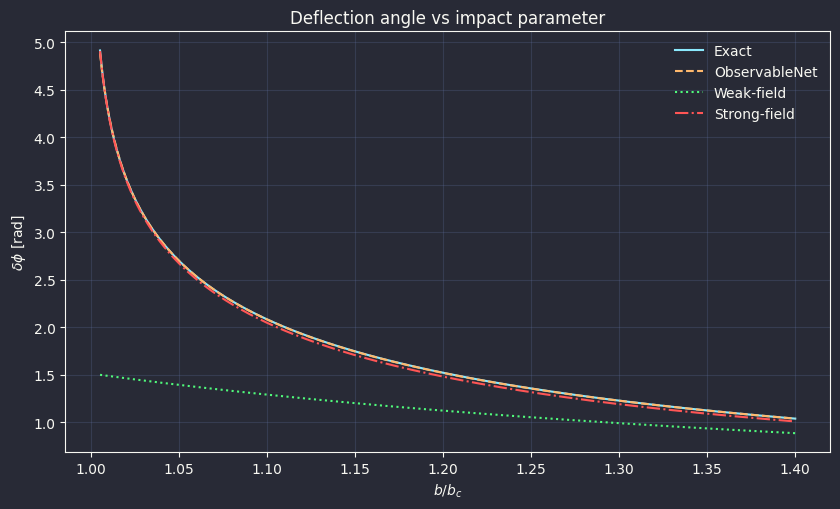

In [5]:
plt.figure(figsize=(8.5, 5.2))
plt.plot(bench_df["b_over_bc"], bench_df["delta_exact"], label="Exact")
plt.plot(bench_df["b_over_bc"], bench_df["delta_pred"], "--", label="ObservableNet")
plt.plot(bench_df["b_over_bc"], bench_df["delta_weak"], ":", label="Weak-field")
plt.plot(bench_df["b_over_bc"], bench_df["delta_strong"], "-.", label="Strong-field")
plt.xlabel(r"$b/b_c$")
plt.ylabel(r"$\delta\phi$ [rad]")
plt.title("Deflection angle vs impact parameter")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, "delta_vs_b_final.png"), dpi=300)
plt.show()

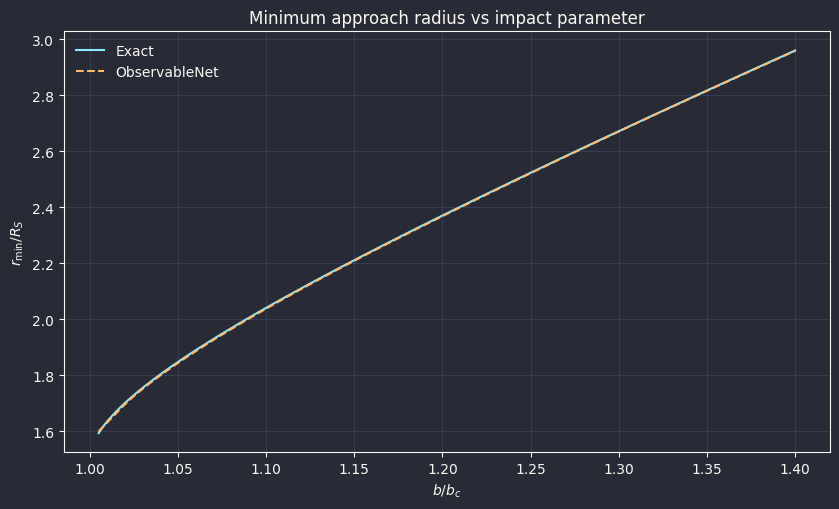

In [7]:
plt.figure(figsize=(8.5, 5.2))
plt.plot(bench_df["b_over_bc"], bench_df["rho_min_exact"], label="Exact")
plt.plot(bench_df["b_over_bc"], bench_df["rho_min_pred"], "--", label="ObservableNet")
plt.xlabel(r"$b/b_c$")
plt.ylabel(r"$r_{\min}/R_S$")
plt.title("Minimum approach radius vs impact parameter")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, "rmin_vs_b_final.png"), dpi=300)
plt.show()

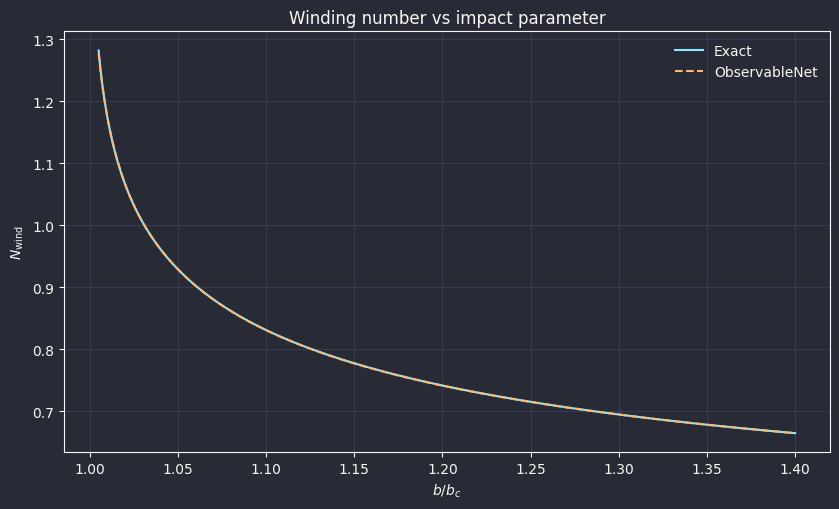

In [8]:
plt.figure(figsize=(8.5, 5.2))
plt.plot(bench_df["b_over_bc"], bench_df["N_wind_exact"], label="Exact")
plt.plot(bench_df["b_over_bc"], bench_df["N_wind_pred"], "--", label="ObservableNet")
plt.xlabel(r"$b/b_c$")
plt.ylabel(r"$N_{\rm wind}$")
plt.title("Winding number vs impact parameter")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, "winding_vs_b_final.png"), dpi=300)
plt.show()

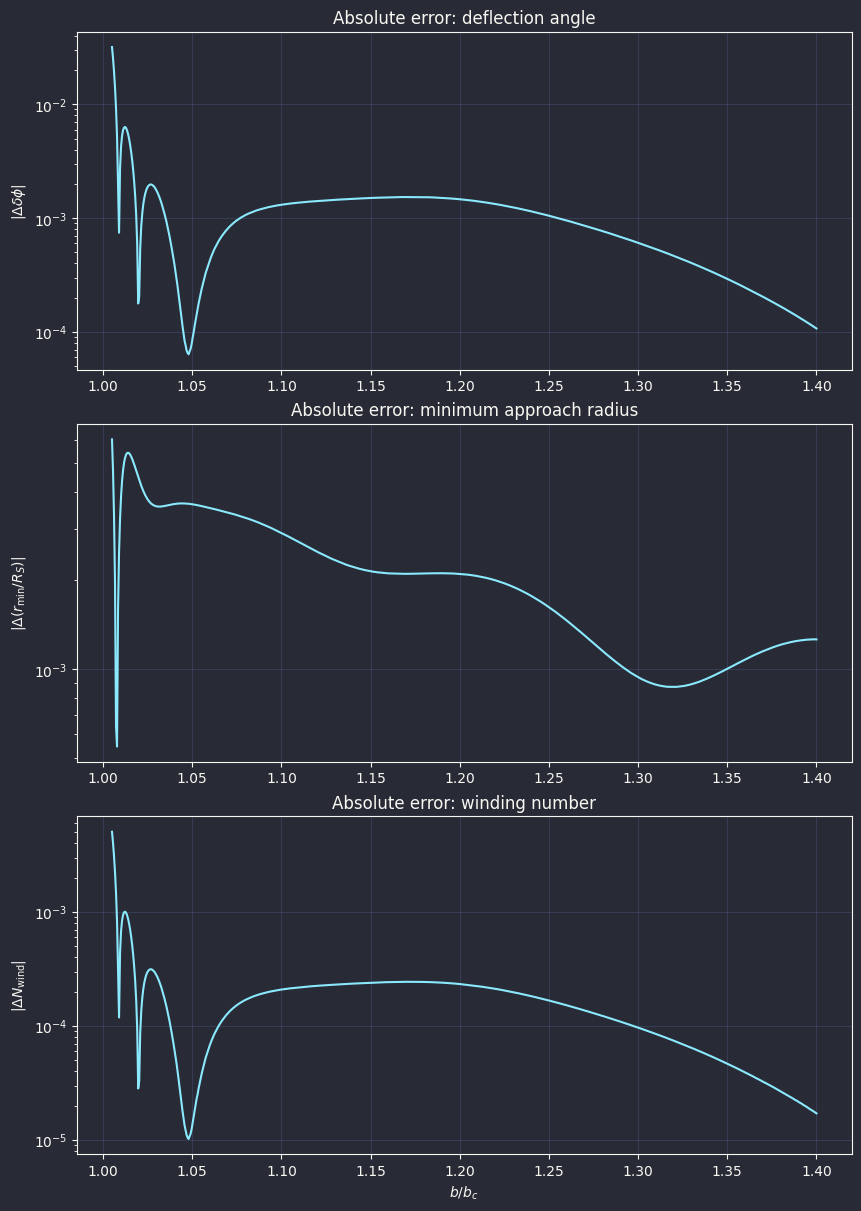

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(8.5, 12), constrained_layout=True)

axes[0].plot(bench_df["b_over_bc"], bench_df["abs_err_delta"])
axes[0].set_yscale("log")
axes[0].set_ylabel(r"$|\Delta \delta\phi|$")
axes[0].set_title("Absolute error: deflection angle")
axes[0].grid(True, alpha=0.25)

axes[1].plot(bench_df["b_over_bc"], bench_df["abs_err_rho_min"])
axes[1].set_yscale("log")
axes[1].set_ylabel(r"$|\Delta (r_{\min}/R_S)|$")
axes[1].set_title("Absolute error: minimum approach radius")
axes[1].grid(True, alpha=0.25)

axes[2].plot(bench_df["b_over_bc"], bench_df["abs_err_N_wind"])
axes[2].set_yscale("log")
axes[2].set_ylabel(r"$|\Delta N_{\rm wind}|$")
axes[2].set_xlabel(r"$b/b_c$")
axes[2].set_title("Absolute error: winding number")
axes[2].grid(True, alpha=0.25)

plt.savefig(os.path.join(OUT_FIGS, "errors_global_final.png"), dpi=300)
plt.show()

In [10]:
b_grid_crit = np.linspace(1.001 * bc, 1.05 * bc, 800)

exact_rows_crit = [scattering_observables_exact(Rs_bench, b) for b in b_grid_crit]
exact_df_crit = pd.DataFrame(exact_rows_crit)

pred_crit = predict_observables(model, norm_info, Rs_bench, b_grid_crit, device=DEVICE)

crit_df = pd.DataFrame({
    "b": b_grid_crit,
    "b_over_bc": b_grid_crit / bc,

    "delta_exact": exact_df_crit["delta_phi"].values,
    "delta_pred": pred_crit["delta_phi"],

    "rho_min_exact": exact_df_crit["rho_min"].values,
    "rho_min_pred": pred_crit["rho_min"],

    "N_wind_exact": exact_df_crit["N_wind"].values,
    "N_wind_pred": pred_crit["N_wind"].values if isinstance(pred_crit["N_wind"], pd.Series) else pred_crit["N_wind"],
})

crit_df["abs_err_delta"] = np.abs(crit_df["delta_pred"] - crit_df["delta_exact"])
crit_df["abs_err_rho_min"] = np.abs(crit_df["rho_min_pred"] - crit_df["rho_min_exact"])
crit_df["abs_err_N_wind"] = np.abs(crit_df["N_wind_pred"] - crit_df["N_wind_exact"])

crit_df.head()

,b,b_over_bc,delta_exact,delta_pred,rho_min_exact,rho_min_pred,N_wind_exact,N_wind_pred,abs_err_delta,abs_err_rho_min,abs_err_N_wind
0,2.600674,1.001000,6.510645,6.664715,1.540084,1.493250,1.536201,1.560722,0.154070,0.046834,0.024521
1,2.600834,1.001061,6.451299,6.584205,1.541338,1.499117,1.526756,1.547909,0.132906,0.042221,0.021153
2,2.600993,1.001123,6.395296,6.509571,1.542558,1.504518,1.517843,1.536030,0.114275,0.038040,0.018187
3,2.601152,1.001184,6.342281,6.439967,1.543748,1.509519,1.509405,1.524953,0.097686,0.034229,0.015547
4,2.601312,1.001245,6.291952,6.374697,1.544910,1.514169,1.501395,1.514565,0.082745,0.030741,0.013169


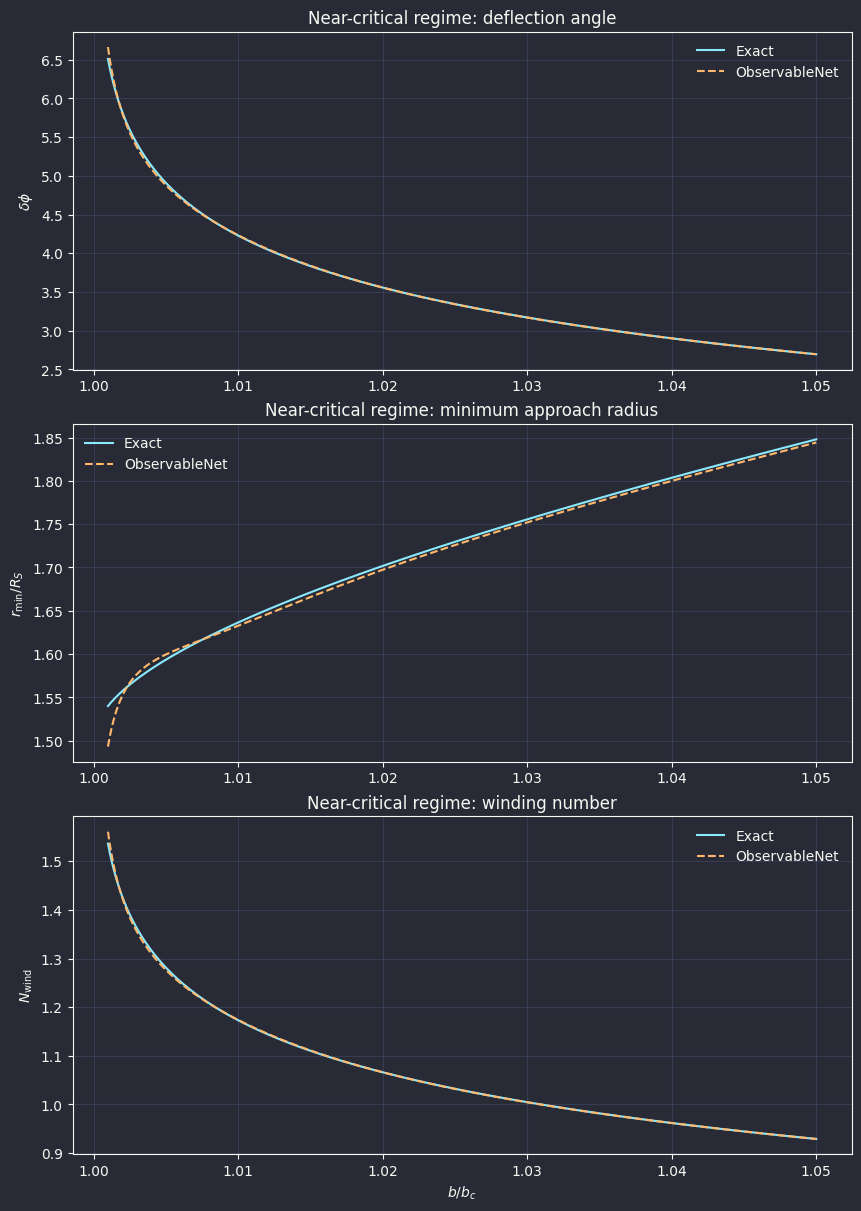

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(8.5, 12), constrained_layout=True)

axes[0].plot(crit_df["b_over_bc"], crit_df["delta_exact"], label="Exact")
axes[0].plot(crit_df["b_over_bc"], crit_df["delta_pred"], "--", label="ObservableNet")
axes[0].set_ylabel(r"$\delta\phi$")
axes[0].set_title("Near-critical regime: deflection angle")
axes[0].grid(True, alpha=0.25)
axes[0].legend()

axes[1].plot(crit_df["b_over_bc"], crit_df["rho_min_exact"], label="Exact")
axes[1].plot(crit_df["b_over_bc"], crit_df["rho_min_pred"], "--", label="ObservableNet")
axes[1].set_ylabel(r"$r_{\min}/R_S$")
axes[1].set_title("Near-critical regime: minimum approach radius")
axes[1].grid(True, alpha=0.25)
axes[1].legend()

axes[2].plot(crit_df["b_over_bc"], crit_df["N_wind_exact"], label="Exact")
axes[2].plot(crit_df["b_over_bc"], crit_df["N_wind_pred"], "--", label="ObservableNet")
axes[2].set_ylabel(r"$N_{\rm wind}$")
axes[2].set_xlabel(r"$b/b_c$")
axes[2].set_title("Near-critical regime: winding number")
axes[2].grid(True, alpha=0.25)
axes[2].legend()

plt.savefig(os.path.join(OUT_FIGS, "critical_observables_zoom.png"), dpi=300)
plt.show()

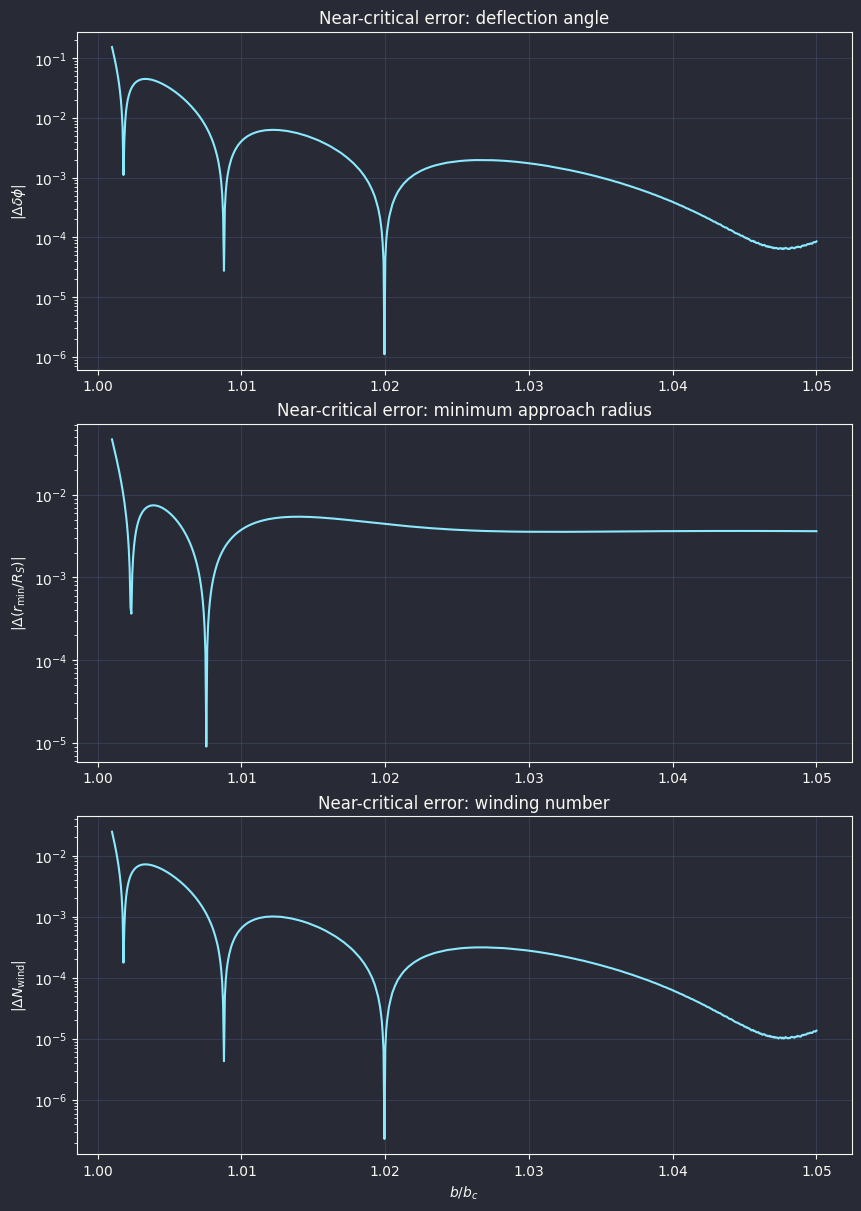

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(8.5, 12), constrained_layout=True)

axes[0].plot(crit_df["b_over_bc"], crit_df["abs_err_delta"])
axes[0].set_yscale("log")
axes[0].set_ylabel(r"$|\Delta \delta\phi|$")
axes[0].set_title("Near-critical error: deflection angle")
axes[0].grid(True, alpha=0.25)

axes[1].plot(crit_df["b_over_bc"], crit_df["abs_err_rho_min"])
axes[1].set_yscale("log")
axes[1].set_ylabel(r"$|\Delta (r_{\min}/R_S)|$")
axes[1].set_title("Near-critical error: minimum approach radius")
axes[1].grid(True, alpha=0.25)

axes[2].plot(crit_df["b_over_bc"], crit_df["abs_err_N_wind"])
axes[2].set_yscale("log")
axes[2].set_ylabel(r"$|\Delta N_{\rm wind}|$")
axes[2].set_xlabel(r"$b/b_c$")
axes[2].set_title("Near-critical error: winding number")
axes[2].grid(True, alpha=0.25)

plt.savefig(os.path.join(OUT_FIGS, "critical_errors_zoom.png"), dpi=300)
plt.show()

In [13]:
summary_table = pd.DataFrame({
    "Observable": [r"$\delta\phi$", r"$r_{\min}/R_S$", r"$N_{\rm wind}$"],
    "Mean abs. error (global benchmark)": [
        bench_df["abs_err_delta"].mean(),
        bench_df["abs_err_rho_min"].mean(),
        bench_df["abs_err_N_wind"].mean(),
    ],
    "Mean abs. error (critical zoom)": [
        crit_df["abs_err_delta"].mean(),
        crit_df["abs_err_rho_min"].mean(),
        crit_df["abs_err_N_wind"].mean(),
    ],
})

summary_table

,Observable,Mean abs. error (global benchmark),Mean abs. error (critical zoom)
0,$\delta\phi$,0.001150,0.005900
1,$r_{\min}/R_S$,0.002103,0.004348
2,$N_{\rm wind}$,0.000183,0.000939


In [ ]:
# summary_table.to_csv(os.path.join(BASE, "tables", "paper_summary_observables.csv"), index=False)